# Exp-4 Analysis  —  Dual-Deep (baseline) vs Deep-v6

分析 `exp4` 的 paper-config 全量实验结果。

- baseline vs 改进版：`exp4` = dual-deep vs deep-v6
- 每张图按维度 D1..D8 拆分（见 `report/` 的 plan）
- 所有图自动落到 `./charts/`

In [1]:
EXP_NAME = "exp4"
import sys
sys.path.insert(0, '..')
from _style import *

CHART_DIR = Path('charts')
CHART_DIR.mkdir(exist_ok=True)

# EXP_NAME is defined below per notebook
CSV_PATH = EXP4_CSV if EXP_NAME == 'exp4' else EXP5_CSV
IMP_NAME = 'deep-v6' if EXP_NAME == 'exp4' else 'fast-v19'
BASE_NAME = 'dual-deep' if EXP_NAME == 'exp4' else 'dual-fast'
IMP_COLOR = GREEN if EXP_NAME == 'exp4' else BLUE
BASE_COLOR = GRAY
TAG = 'v6' if EXP_NAME == 'exp4' else 'v19'

df = load_exp(CSV_PATH)
print(f'loaded {len(df)} rows, solvers={df.solver.unique().tolist()}')

imp = per_instance(df, IMP_NAME)
base = per_instance(df, BASE_NAME)
merged = pairwise(imp, base)
print(f'per-instance: imp={len(imp)}  base={len(base)}  merged={len(merged)}')
print('win:', merged.win.value_counts().to_dict())
print('cause:', merged.cause.value_counts().to_dict())


loaded 4287 rows, solvers=['dual-deep', 'deep-v6']


per-instance: imp=1074  base=1080  merged=1074
win: {1: 777, 0: 282, -1: 15}
cause: {'LB-driven': 747, 'Neither': 298, 'Both': 23, 'UB-driven': 6}


## D1 总体效果

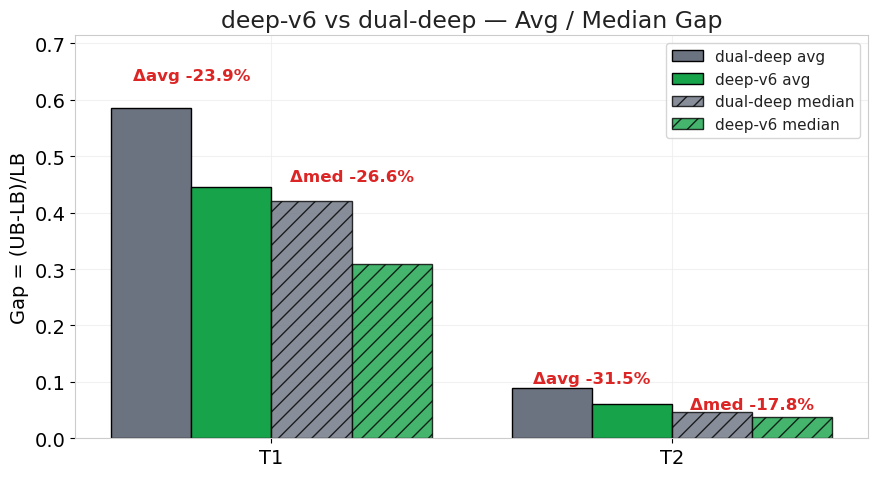

In [2]:
# ## 4-01 / 5-01 — Avg + Median Gap Bar
# ---
# 数据源：当前 exp 的 per-instance 聚合（imp vs base）
# 字段：gap (seed-avg) -> per-dataset avg 和 median
# 视觉：每 dataset 两 bar pair（avg 实心 / median 斜纹）；上方标 Δ% (imp − base) / base * 100

fig, ax = plt.subplots(figsize=(9, 5))
datasets = ['T1', 'T2']
x = np.arange(len(datasets)) * 1.6
w = 0.32

avg_imp = [imp[imp.dataset == d]['gap'].mean() for d in datasets]
avg_base = [base[base.dataset == d]['gap'].mean() for d in datasets]
med_imp = [imp[imp.dataset == d]['gap'].median() for d in datasets]
med_base = [base[base.dataset == d]['gap'].median() for d in datasets]

ax.bar(x - 1.5*w, avg_base, w, label=f'{BASE_NAME} avg',
       color=BASE_COLOR, edgecolor='black', linewidth=1)
ax.bar(x - 0.5*w, avg_imp, w, label=f'{IMP_NAME} avg',
       color=IMP_COLOR, edgecolor='black', linewidth=1)
ax.bar(x + 0.5*w, med_base, w, label=f'{BASE_NAME} median',
       color=BASE_COLOR, edgecolor='black', linewidth=1, hatch='//', alpha=0.8)
ax.bar(x + 1.5*w, med_imp, w, label=f'{IMP_NAME} median',
       color=IMP_COLOR, edgecolor='black', linewidth=1, hatch='//', alpha=0.8)

# Δ% annotations on avg bars
for i, d in enumerate(datasets):
    pct = (avg_imp[i] - avg_base[i]) / avg_base[i] * 100 if avg_base[i] else 0
    ytop = max(avg_base[i], avg_imp[i]) * 1.08 + 0.002
    ax.annotate(f'Δavg {pct:+.1f}%', (x[i] - w, ytop), ha='center',
                fontsize=12, color=RED if pct < 0 else GREEN, fontweight='bold')
    pct_m = (med_imp[i] - med_base[i]) / max(med_base[i], 1e-9) * 100
    ytop_m = max(med_base[i], med_imp[i]) * 1.08 + 0.002
    ax.annotate(f'Δmed {pct_m:+.1f}%', (x[i] + w, ytop_m), ha='center',
                fontsize=12, color=RED if pct_m < 0 else GREEN, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('Gap = (UB-LB)/LB')
ax.set_title(f'{IMP_NAME} vs {BASE_NAME} — Avg / Median Gap')
ax.set_ylim(0, max(max(avg_base), max(avg_imp)) * 1.22)
ax.legend(loc='upper right', frameon=True, fontsize=11)
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, f'{TAG}-01-avg-median-gap.png')


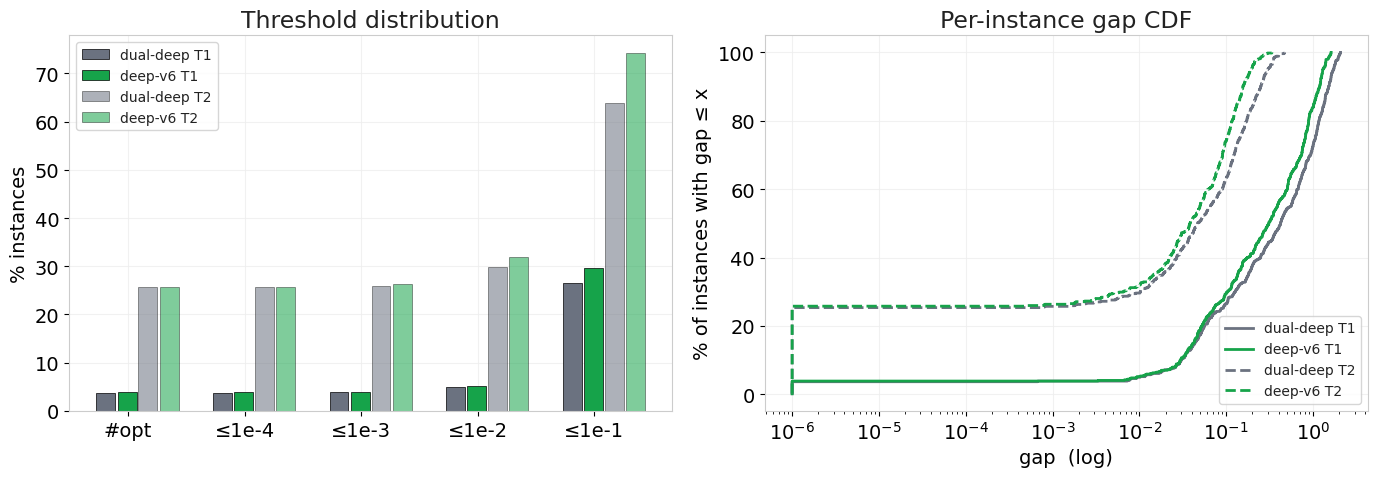

In [3]:
# ## 4-02 / 5-02 — Threshold Distribution (Table 3 format) + Gap CDF
# ---
# 左：每档 (#opt / ≤1e-4 / ≤1e-3 / ≤1e-2 / ≤1e-1) 的实例比例
# 右：逐实例 gap 的累计分布函数 (CDF，log x 轴)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左：阈值分档比例 ---
ax = axes[0]
labels = [t[0] for t in THRESHOLDS]
x = np.arange(len(labels))
w = 0.36
for d_idx, d in enumerate(['T1', 'T2']):
    t_imp = threshold_table(imp[imp.dataset == d])
    t_base = threshold_table(base[base.dataset == d])
    n = t_imp['n'].iloc[0]
    pct_imp = [t_imp[l].iloc[0] / n * 100 for l in labels]
    pct_base = [t_base[l].iloc[0] / n * 100 for l in labels]
    offset = -w/2 + d_idx * w
    ax.bar(x + offset - 0.01, pct_base, w*0.45, label=f'{BASE_NAME} {d}',
           color=BASE_COLOR, edgecolor='black', linewidth=0.5,
           alpha=0.55 if d == 'T2' else 1.0)
    ax.bar(x + offset + w*0.48, pct_imp, w*0.45, label=f'{IMP_NAME} {d}',
           color=IMP_COLOR, edgecolor='black', linewidth=0.5,
           alpha=0.55 if d == 'T2' else 1.0)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('% instances')
ax.set_title('Threshold distribution')
ax.legend(fontsize=10, loc='upper left')
ax.set_axisbelow(True)

# --- 右：gap CDF (log x) ---
ax2 = axes[1]
for d, ls in zip(['T1', 'T2'], ['-', '--']):
    for sv, col in [(base, BASE_COLOR), (imp, IMP_COLOR)]:
        vals = sv[sv.dataset == d]['gap'].values
        vals = np.sort(np.clip(vals, 1e-6, None))
        ys = np.arange(1, len(vals)+1) / len(vals) * 100
        name = BASE_NAME if sv is base else IMP_NAME
        ax2.step(vals, ys, where='post', linestyle=ls,
                 color=col, linewidth=2, label=f'{name} {d}')
ax2.set_xscale('log')
ax2.set_xlabel('gap  (log)')
ax2.set_ylabel('% of instances with gap ≤ x')
ax2.set_title('Per-instance gap CDF')
ax2.legend(fontsize=10, loc='lower right')
ax2.set_axisbelow(True)

save_show(fig, CHART_DIR, f'{TAG}-02-threshold-cdf.png')


## D2 逐实例胜负

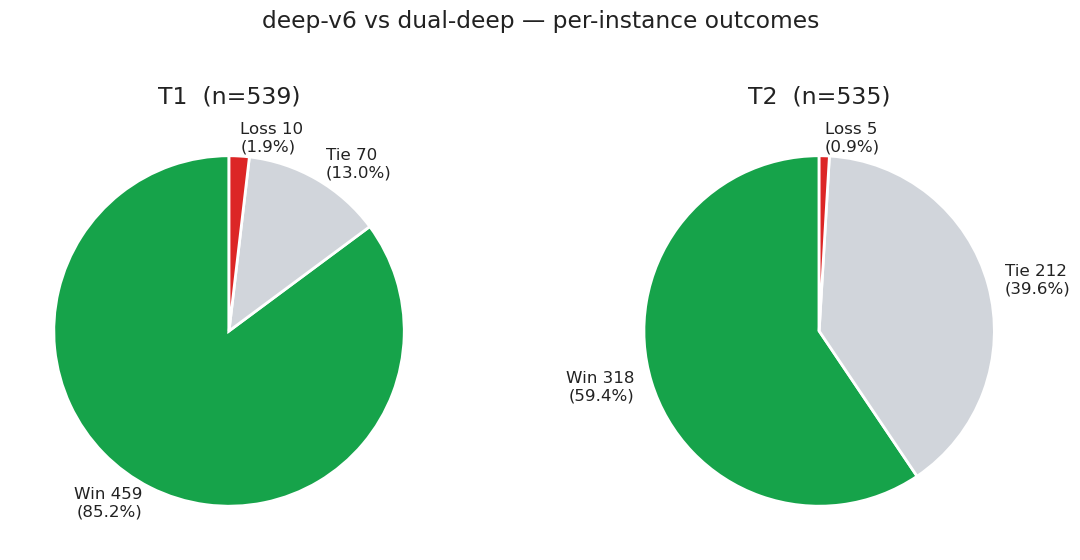

In [4]:
# ## 4-03 / 5-03 — Per-instance Win / Tie / Loss
# ---
# tie 阈值：|d_gap| <= 1e-6  (见 _style.pairwise)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, d in zip(axes, ['T1', 'T2']):
    sub = merged[merged.dataset == d]
    w = (sub.win == 1).sum()
    t = (sub.win == 0).sum()
    l = (sub.win == -1).sum()
    n = len(sub)
    colors = [IMP_COLOR, LIGHT_GRAY, RED]
    labels = [f'Win {w}\n({w/n*100:.1f}%)',
              f'Tie {t}\n({t/n*100:.1f}%)',
              f'Loss {l}\n({l/n*100:.1f}%)']
    ax.pie([w, t, l], labels=labels, colors=colors, startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2),
           textprops=dict(fontsize=12))
    ax.set_title(f'{d}  (n={n})')

fig.suptitle(f'{IMP_NAME} vs {BASE_NAME} — per-instance outcomes', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-03-win-tie-loss.png')


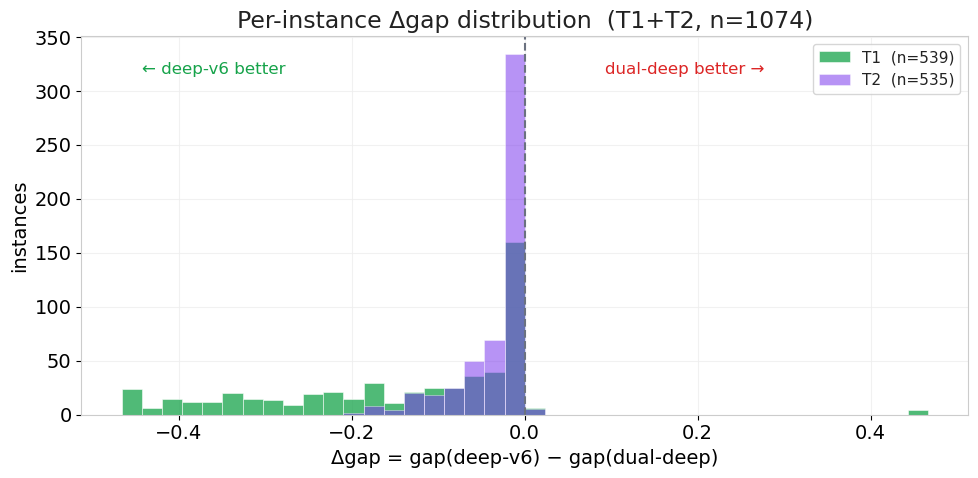

In [5]:
# ## 4-04 / 5-04 — Per-instance Δgap Histogram
# ---
# x = gap_imp − gap_base  (负 = 改进赢)
# 按 dataset 双色堆叠；对称截断到 ±max(|d_gap|) * 0.99 防异常极值拉宽

fig, ax = plt.subplots(figsize=(10, 5))
dvals = merged['d_gap'].values
lim = np.quantile(np.abs(dvals), 0.98) if len(dvals) else 1
bins = np.linspace(-lim, lim, 41)

for d, col, al in [('T1', IMP_COLOR, 0.75), ('T2', PURPLE, 0.55)]:
    sub = merged[merged.dataset == d]
    ax.hist(np.clip(sub['d_gap'], -lim, lim), bins=bins, color=col,
            alpha=al, edgecolor='white', linewidth=0.5, label=f'{d}  (n={len(sub)})')

ax.axvline(0, color=GRAY, linestyle='--', linewidth=1.5)
ax.text(-lim*0.95, ax.get_ylim()[1]*0.9, f'← {IMP_NAME} better', color=GREEN, fontsize=12)
ax.text(lim*0.2, ax.get_ylim()[1]*0.9, f'{BASE_NAME} better →', color=RED, fontsize=12)

ax.set_xlabel(f'Δgap = gap({IMP_NAME}) − gap({BASE_NAME})')
ax.set_ylabel('instances')
ax.set_title(f'Per-instance Δgap distribution  (T1+T2, n={len(merged)})')
ax.legend(fontsize=11)
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, f'{TAG}-04-dgap-histogram.png')


## D3 LB / UB 分解

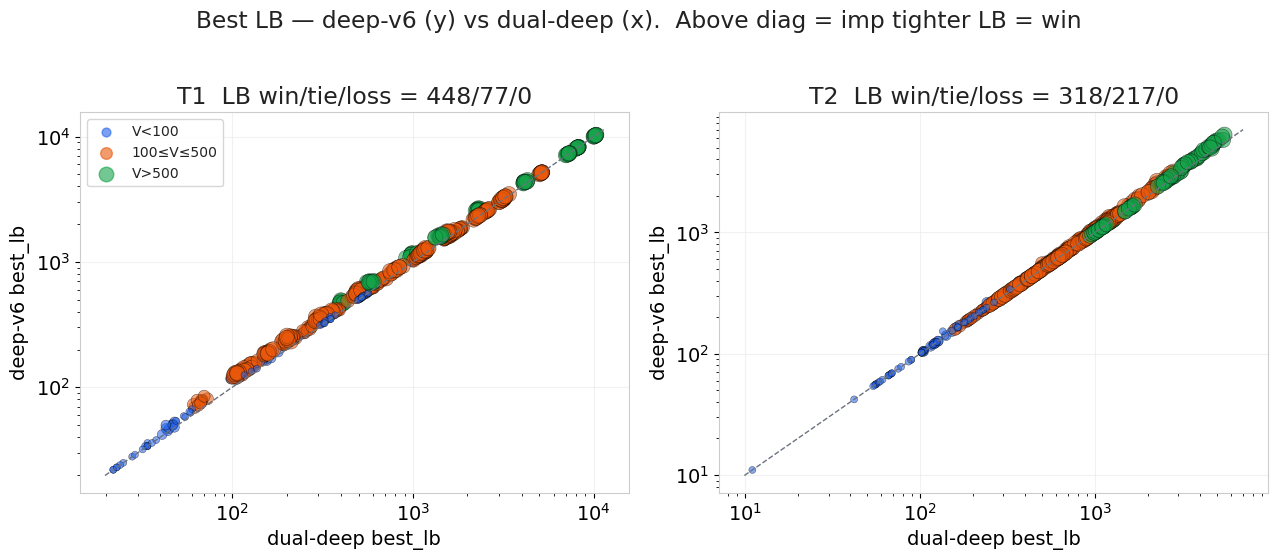

In [6]:
# ## 4-05 / 5-05 — LB Scatter: imp vs baseline
# ---
# 点色按 V 分级；对角线参考；右下方 = imp LB 更紧（加权更大 = 更接近 opt，赢）
# 用 log-log 防 50-250 小实例被大实例压扁

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=False, sharey=False)

for ax, d in zip(axes, ['T1', 'T2']):
    sub = merged[merged.dataset == d].copy()
    sub = sub[(sub['best_lb_base'] > 0) & (sub['best_lb_imp'] > 0)]
    sizes = np.clip(sub['V'] / 2, 8, 120)
    colors = [GREEN if v > 500 else (ORANGE if v > 100 else BLUE) for v in sub['V']]
    ax.scatter(sub['best_lb_base'], sub['best_lb_imp'],
               s=sizes, c=colors, alpha=0.55, edgecolor='black', linewidth=0.4)
    # diagonal
    lo = min(sub['best_lb_base'].min(), sub['best_lb_imp'].min()) * 0.9
    hi = max(sub['best_lb_base'].max(), sub['best_lb_imp'].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], color=GRAY, linestyle='--', linewidth=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'{BASE_NAME} best_lb')
    ax.set_ylabel(f'{IMP_NAME} best_lb')
    wins = (sub['best_lb_imp'] > sub['best_lb_base']).sum()
    ties = (sub['best_lb_imp'] == sub['best_lb_base']).sum()
    loss = (sub['best_lb_imp'] < sub['best_lb_base']).sum()
    ax.set_title(f'{d}  LB win/tie/loss = {wins}/{ties}/{loss}')
    ax.set_axisbelow(True)
# legend for color bins
for ax in axes:
    ax.scatter([], [], c=BLUE, s=40, alpha=0.6, label='V<100')
    ax.scatter([], [], c=ORANGE, s=70, alpha=0.6, label='100≤V≤500')
    ax.scatter([], [], c=GREEN, s=110, alpha=0.6, label='V>500')
axes[0].legend(loc='upper left', fontsize=10)
fig.suptitle(f'Best LB — {IMP_NAME} (y) vs {BASE_NAME} (x).  Above diag = imp tighter LB = win', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-05-lb-scatter.png')


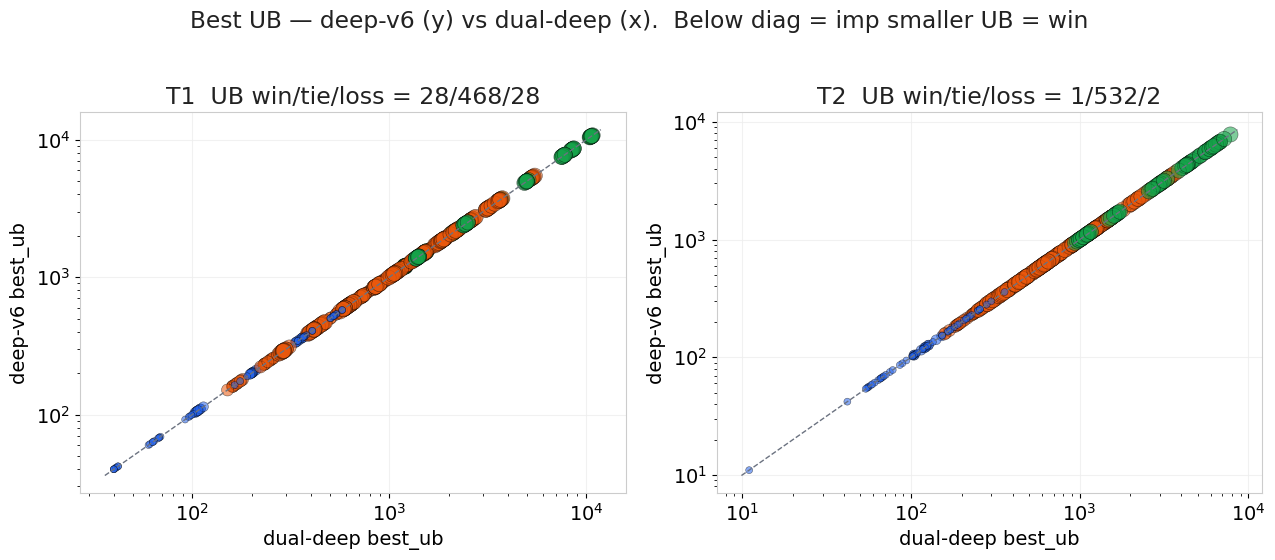

In [7]:
# ## 4-06 / 5-06 — UB Scatter: imp vs baseline
# ---
# 下方 = imp UB 更小（赢）；点多贴近对角线 = "UB 几乎没动"，结合 LB scatter 印证"LB 主导"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=False, sharey=False)
for ax, d in zip(axes, ['T1', 'T2']):
    sub = merged[merged.dataset == d].copy()
    sub = sub[(sub['best_ub_base'] > 0) & (sub['best_ub_imp'] > 0)]
    sizes = np.clip(sub['V'] / 2, 8, 120)
    colors = [GREEN if v > 500 else (ORANGE if v > 100 else BLUE) for v in sub['V']]
    ax.scatter(sub['best_ub_base'], sub['best_ub_imp'],
               s=sizes, c=colors, alpha=0.55, edgecolor='black', linewidth=0.4)
    lo = min(sub['best_ub_base'].min(), sub['best_ub_imp'].min()) * 0.9
    hi = max(sub['best_ub_base'].max(), sub['best_ub_imp'].max()) * 1.1
    ax.plot([lo, hi], [lo, hi], color=GRAY, linestyle='--', linewidth=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'{BASE_NAME} best_ub')
    ax.set_ylabel(f'{IMP_NAME} best_ub')
    wins = (sub['best_ub_imp'] < sub['best_ub_base']).sum()
    ties = (sub['best_ub_imp'] == sub['best_ub_base']).sum()
    loss = (sub['best_ub_imp'] > sub['best_ub_base']).sum()
    ax.set_title(f'{d}  UB win/tie/loss = {wins}/{ties}/{loss}')
    ax.set_axisbelow(True)
fig.suptitle(f'Best UB — {IMP_NAME} (y) vs {BASE_NAME} (x).  Below diag = imp smaller UB = win', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-06-ub-scatter.png')


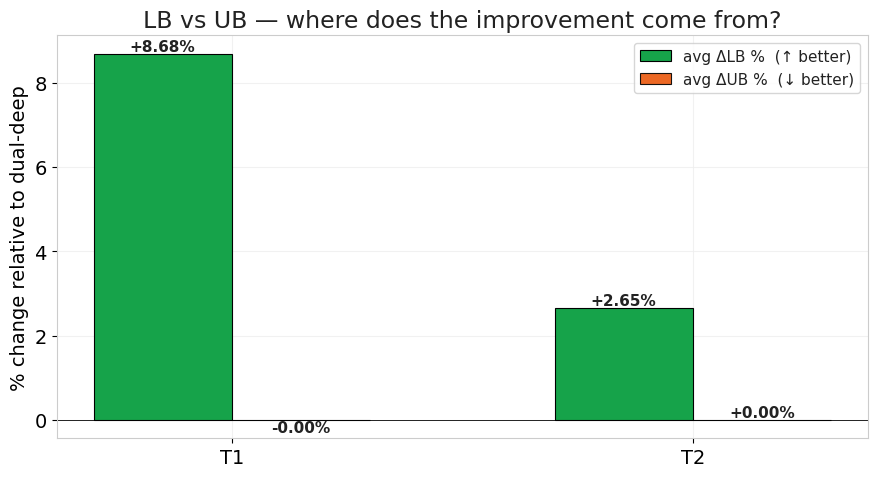

In [8]:
# ## 4-07 / 5-07 — Avg ΔLB% vs Avg ΔUB%  (dual-axis equivalent)
# ---
# 同一图两组柱：ΔLB / LB_base * 100%  (正 = imp LB 更紧 → 想大)
#              ΔUB / UB_base * 100%  (负 = imp UB 更小 → 想小)
# 期望：ΔLB% >> 0, ΔUB% ≈ 0  →  改进主因是 LB

fig, ax = plt.subplots(figsize=(9, 5))
datasets = ['T1', 'T2']
x = np.arange(len(datasets)) * 1.4
w = 0.42

lb_pct = []
ub_pct = []
for d in datasets:
    sub = merged[merged.dataset == d]
    sub = sub[(sub['best_lb_base'] > 0) & (sub['best_ub_base'] > 0)]
    lb_pct.append(((sub['best_lb_imp'] - sub['best_lb_base']) / sub['best_lb_base']).mean() * 100)
    ub_pct.append(((sub['best_ub_imp'] - sub['best_ub_base']) / sub['best_ub_base']).mean() * 100)

b1 = ax.bar(x - w/2, lb_pct, w, label='avg ΔLB %  (↑ better)',
            color=IMP_COLOR, edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + w/2, ub_pct, w, label='avg ΔUB %  (↓ better)',
            color=ORANGE, edgecolor='black', linewidth=0.8, alpha=0.9)
for b, v in zip(b1, lb_pct):
    ax.annotate(f'{v:+.2f}%', (b.get_x() + b.get_width()/2, v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=11, fontweight='bold')
for b, v in zip(b2, ub_pct):
    ax.annotate(f'{v:+.2f}%', (b.get_x() + b.get_width()/2, v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=11, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(datasets)
ax.set_ylabel(f'% change relative to {BASE_NAME}')
ax.set_title(f'LB vs UB — where does the improvement come from?')
ax.legend(fontsize=11, loc='upper right')
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, f'{TAG}-07-lb-ub-pct.png')


## D4 规模效应 (V)

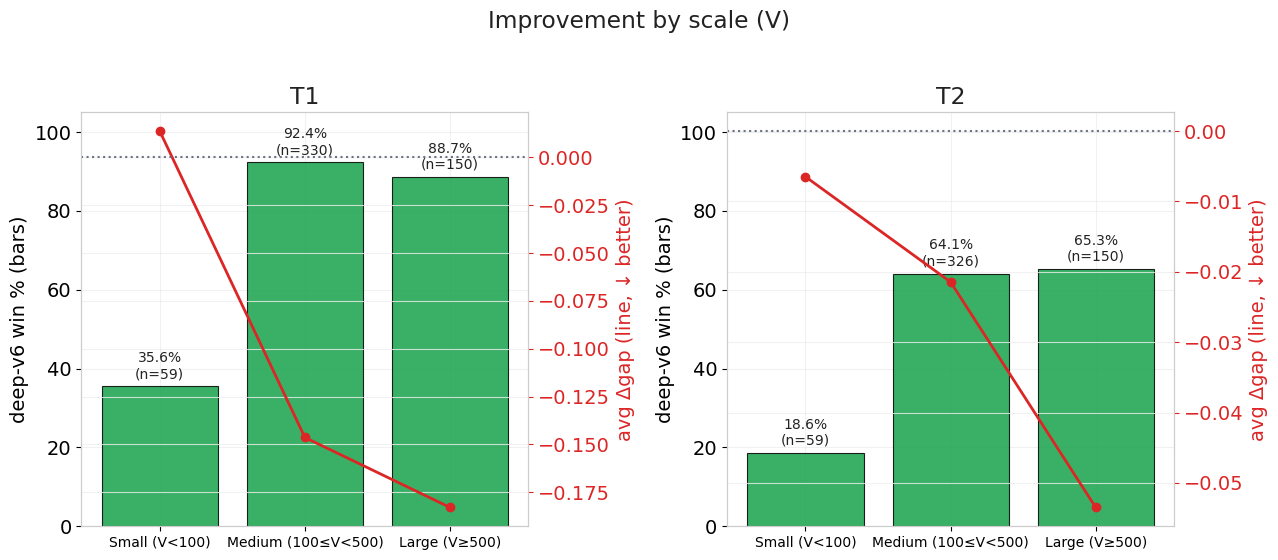

In [9]:
# ## 4-08 / 5-08 — Improvement by V (node count) scale
# ---
# 3 档：Small(V<100) / Medium(100≤V<500) / Large(V≥500)
# bar = win%；折线 = avg Δgap（负 = imp 赢越多）

merged['Vbucket'] = merged['V'].apply(v_bucket)
order = ['Small (V<100)', 'Medium (100≤V<500)', 'Large (V≥500)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, d in zip(axes, ['T1', 'T2']):
    sub = merged[merged.dataset == d]
    win_pct, avg_dgap, counts = [], [], []
    for b in order:
        s = sub[sub.Vbucket == b]
        counts.append(len(s))
        win_pct.append((s.win == 1).mean() * 100 if len(s) else 0)
        avg_dgap.append(s.d_gap.mean() if len(s) else 0)
    x = np.arange(len(order))
    ax.bar(x, win_pct, color=IMP_COLOR, edgecolor='black', linewidth=0.8,
           alpha=0.85, label=f'{IMP_NAME} win %')
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=0, fontsize=10)
    ax.set_ylabel(f'{IMP_NAME} win % (bars)')
    ax.set_ylim(0, 105)
    for xi, wp, n in zip(x, win_pct, counts):
        ax.annotate(f'{wp:.1f}%\n(n={n})', (xi, wp + 2), ha='center', fontsize=10)
    ax2 = ax.twinx()
    ax2.plot(x, avg_dgap, marker='o', color=RED, linewidth=2, label='avg Δgap')
    ax2.axhline(0, color=GRAY, linestyle=':')
    ax2.set_ylabel('avg Δgap (line, ↓ better)', color=RED)
    ax2.tick_params(axis='y', colors=RED)
    ax.set_title(f'{d}')
    ax.set_axisbelow(True)

fig.suptitle('Improvement by scale (V)', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-08-improvement-by-V.png')


## D5 密度效应 (E/V)

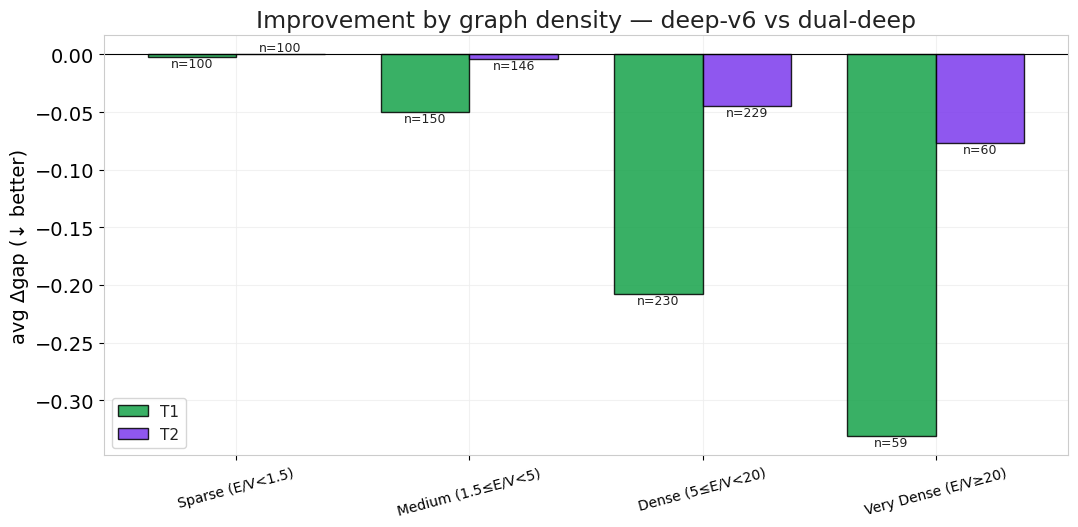

In [10]:
# ## 4-09 / 5-09 — Improvement by E/V density
# ---
# 密度 = E/V；分桶后折线 avg Δgap 看 "我们的方法在哪种图上最有用"

merged['EV'] = merged['E'] / merged['V'].replace(0, np.nan)
merged['dbucket'] = merged['EV'].apply(lambda x: density_bucket(x) if pd.notna(x) else 'Unknown')
order = ['Sparse (E/V<1.5)', 'Medium (1.5≤E/V<5)', 'Dense (5≤E/V<20)', 'Very Dense (E/V≥20)']

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(order))
w = 0.38
for i, d in enumerate(['T1', 'T2']):
    sub = merged[merged.dataset == d]
    avg_dg = [sub[sub.dbucket == b]['d_gap'].mean() if (sub.dbucket == b).any() else np.nan
              for b in order]
    counts = [(sub.dbucket == b).sum() for b in order]
    col = IMP_COLOR if d == 'T1' else PURPLE
    bars = ax.bar(x + (-w/2 if d == 'T1' else w/2), avg_dg, w, color=col,
                  edgecolor='black', alpha=0.85, label=f'{d}')
    for xi, v, n, b in zip(x, avg_dg, counts, bars):
        if pd.notna(v):
            off = (w/2 if d == 'T2' else -w/2)
            ax.annotate(f'n={n}', (xi + off, v), ha='center',
                        va='top' if v < 0 else 'bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15, fontsize=10)
ax.set_ylabel('avg Δgap (↓ better)')
ax.set_title(f'Improvement by graph density — {IMP_NAME} vs {BASE_NAME}')
ax.legend(fontsize=11)
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, f'{TAG}-09-improvement-by-density.png')


## D6 时序演化

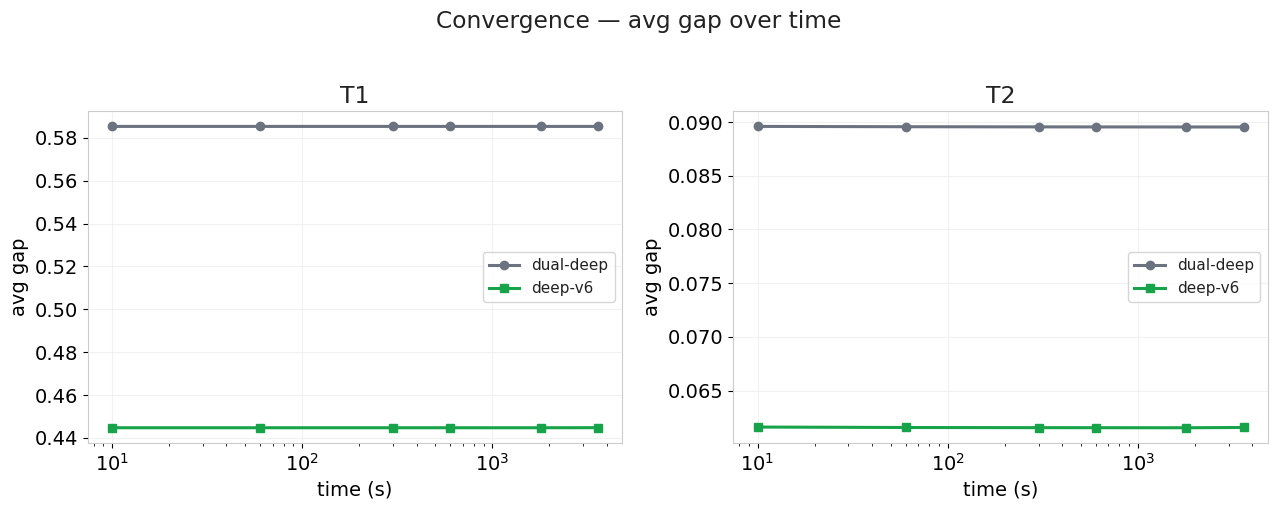

In [11]:
# ## 4-10 / 5-10 — Convergence Curves (gap vs time)
# ---
# 用 CSV 中 gap_{10,60,300,600,1800,3600}s 列；
# 若某行该时刻 checkpoint 为 -1（提前结束或未记录），用最终 gap 前向填充
# 语义：平均到某个时刻全部实例（含已结束）当前最好 gap

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, d in zip(axes, ['T1', 'T2']):
    ts_imp, avg_imp = gap_curve(df, IMP_NAME, d)
    ts_base, avg_base = gap_curve(df, BASE_NAME, d)
    ax.plot(ts_base, avg_base, marker='o', color=BASE_COLOR, linewidth=2.2,
            label=BASE_NAME)
    ax.plot(ts_imp, avg_imp, marker='s', color=IMP_COLOR, linewidth=2.2,
            label=IMP_NAME)
    ax.set_xscale('log')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('avg gap')
    ax.set_title(f'{d}')
    ax.legend(fontsize=11)
    ax.set_axisbelow(True)

fig.suptitle(f'Convergence — avg gap over time', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-10-convergence.png')


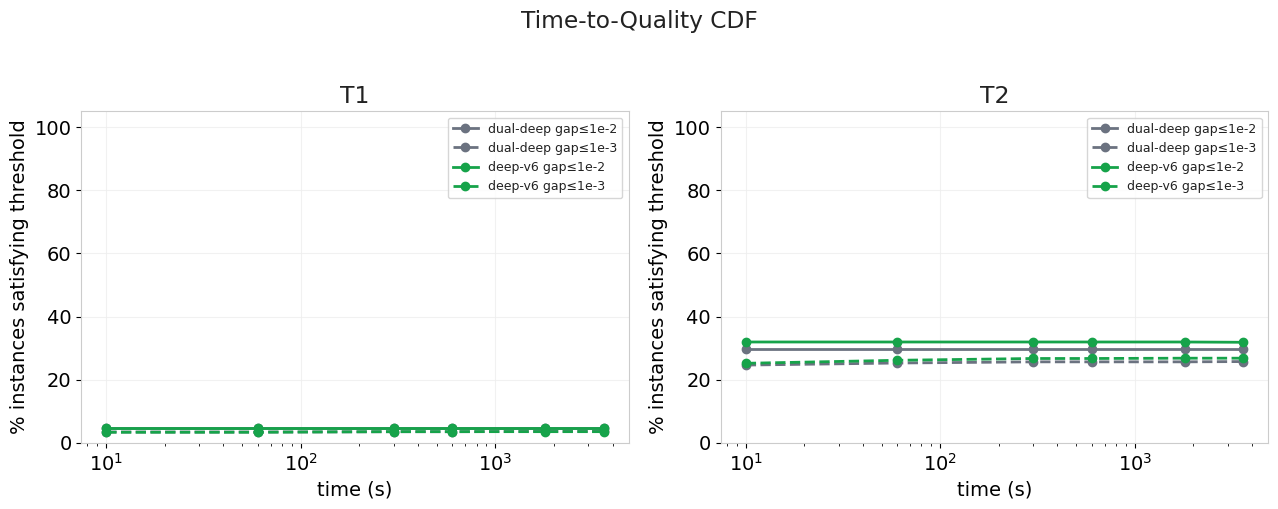

In [12]:
# ## 4-11 / 5-11 — Time-to-Quality CDF
# ---
# 在时刻 t 有多少比例的实例 gap ≤ threshold 了？
# 用 2 个阈值：1e-2 和 1e-3，对两个 solver 各画一对

THRESH_A = 1e-2
THRESH_B = 1e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, d in zip(axes, ['T1', 'T2']):
    for sv_name, col, ls_list in [(BASE_NAME, BASE_COLOR, ['-','--']),
                                   (IMP_NAME, IMP_COLOR, ['-','--'])]:
        sub = df[(df.solver == sv_name) & (df.dataset == d)].copy()
        for c in TIME_COLS:
            mask = sub[c] < 0
            sub.loc[mask, c] = sub.loc[mask, 'gap']
        for thr, lbl, lsi in [(THRESH_A, 'gap≤1e-2', 0), (THRESH_B, 'gap≤1e-3', 1)]:
            frac_t = [(sub[c] <= thr).mean() * 100 for c in TIME_COLS]
            ax.plot(TIME_SECONDS, frac_t, marker='o', color=col,
                    linestyle=ls_list[lsi], linewidth=2,
                    label=f'{sv_name} {lbl}')
    ax.set_xscale('log')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('% instances satisfying threshold')
    ax.set_title(f'{d}')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.set_axisbelow(True)

fig.suptitle('Time-to-Quality CDF', y=1.02)
save_show(fig, CHART_DIR, f'{TAG}-11-time-to-quality.png')


## D7 种子稳定性

/tmp/ipykernel_2345409/2327149945.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, widths=0.6,


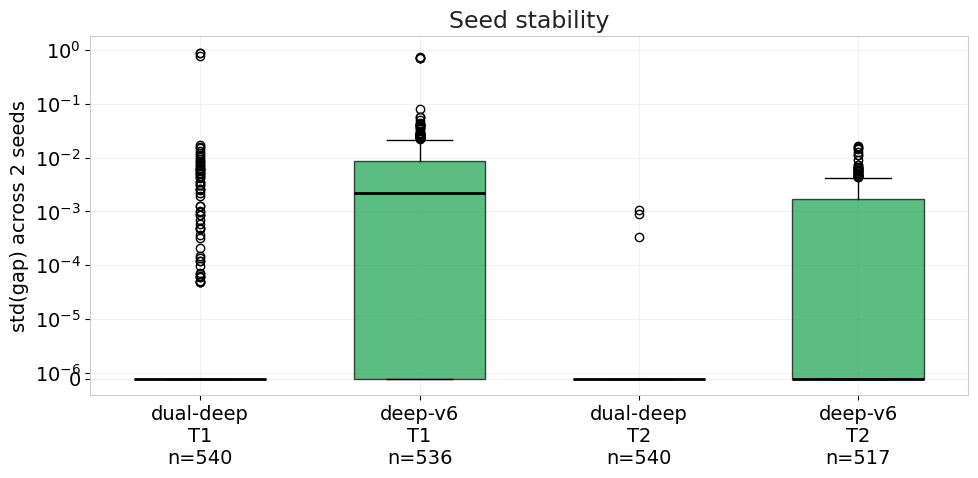

In [13]:
# ## 4-12 / 5-12 — Seed Stability (std of gap across seeds)
# ---
# 每个 (solver, dataset, instance) 在 2 seeds 上算 std(gap)；箱图看分布
# std 越小 = 算法越稳定

rows = []
for (sv, d, inst), g in df.groupby(['solver', 'dataset', 'instance']):
    if g['seed'].nunique() >= 2:
        rows.append({'solver': sv, 'dataset': d, 'std': g['gap'].std(ddof=0)})
stab = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
order_sv = [(BASE_NAME, BASE_COLOR), (IMP_NAME, IMP_COLOR)]
data_box, labels_box, colors_box = [], [], []
for d in ['T1', 'T2']:
    for sv, col in order_sv:
        s = stab[(stab.solver == sv) & (stab.dataset == d)]['std'].values
        data_box.append(s)
        labels_box.append(f'{sv}\n{d}\nn={len(s)}')
        colors_box.append(col)

bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, widths=0.6,
                showfliers=True, medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_ylabel('std(gap) across 2 seeds')
ax.set_title('Seed stability')
ax.set_yscale('symlog', linthresh=1e-5)
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, f'{TAG}-12-seed-stability.png')


## D3 因果总结

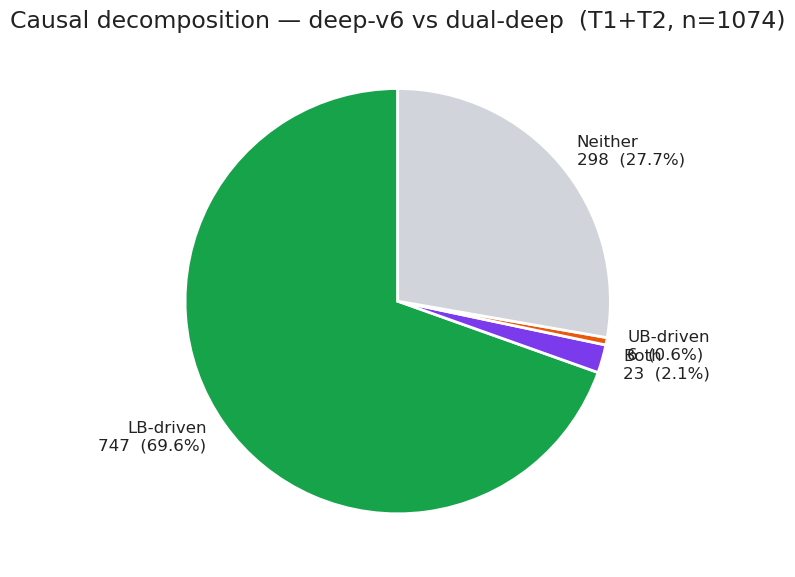

In [14]:
# ## Causal Pie — where does the gap improvement come from?
# ---
# 用 merged.cause：LB-driven / UB-driven / Both / Neither
fig, ax = plt.subplots(figsize=(7, 6))
cats = ['LB-driven', 'Both', 'UB-driven', 'Neither']
sizes = [int((merged.cause == c).sum()) for c in cats]
colors = [IMP_COLOR, PURPLE, ORANGE, LIGHT_GRAY]
total = sum(sizes)
labels = [f'{c}\n{s}  ({s/total*100:.1f}%)' for c, s in zip(cats, sizes)]
ax.pie(sizes, labels=labels, colors=colors, startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2),
       textprops=dict(fontsize=12))
ax.set_title(f'Causal decomposition — {IMP_NAME} vs {BASE_NAME}  (T1+T2, n={total})')
save_show(fig, CHART_DIR, f'{TAG}-causal-pie.png')


## D8 难例子集 (TIMEOUT)

In [15]:
# ## TIMEOUT / Hard-instance subset
# ---
# 只看 status 有 TIMEOUT 的实例（baseline 或 imp 任一方超时）
# 结论模板：这些"难例"上改进是否仍然存在？
hard_inst = set()
for sv in [IMP_NAME, BASE_NAME]:
    sub = df[(df.solver == sv) & (df.status == 'TIMEOUT')]
    hard_inst.update(zip(sub['dataset'], sub['instance']))
print(f'hard (TIMEOUT) instances: {len(hard_inst)}')

if hard_inst:
    mask = merged.apply(lambda r: (r['dataset'], r['instance']) in hard_inst, axis=1)
    hm = merged[mask]
    print('subset size:', len(hm))
    print(hm.groupby('dataset').agg(
        base_avg_gap=('gap_base', 'mean'),
        imp_avg_gap=('gap_imp', 'mean'),
        win_pct=('win', lambda x: (x == 1).mean() * 100),
    ).round(4))
else:
    print('no TIMEOUT instances in this experiment')


hard (TIMEOUT) instances: 15
subset size: 15
         base_avg_gap  imp_avg_gap  win_pct
dataset                                    
T1             -0.831      -0.7055     20.0


## D9 Newly / Lost optimal

In [16]:
# ## Newly optimal instances
# ---
# imp 解到最优 (gap=0) 而 base 没有；列 instance 级清单便于写报告

eps = 1e-9
new_opt = merged[(merged['gap_imp'] <= eps) & (merged['gap_base'] > eps)]
lost_opt = merged[(merged['gap_imp'] > eps) & (merged['gap_base'] <= eps)]

print(f'Newly-optimal (imp solves, base doesn\'t): {len(new_opt)}')
print(new_opt[['dataset','instance','V','E','best_lb_imp','best_ub_imp',
               'best_lb_base','best_ub_base','d_gap']].to_string(index=False))

print(f'\nLost-optimal (base solves, imp doesn\'t): {len(lost_opt)}')
print(lost_opt[['dataset','instance','V','E','best_lb_imp','best_ub_imp',
                'best_lb_base','best_ub_base','d_gap']].to_string(index=False))


Newly-optimal (imp solves, base doesn't): 4
dataset          instance   V    E  best_lb_imp  best_ub_imp  best_lb_base  best_ub_base     d_gap
     T1 T1_150_150_5.wclq 150  150         1486         1486          1485          1486 -0.000673
     T1   T1_50_50_3.wclq  50   50          537          537           527           537 -0.018975
     T2 T2_50_1000_4.wclq  50 1000          107          107           104           107 -0.028846
     T2  T2_50_750_7.wclq  50  750          153          153           135           153 -0.133333

Lost-optimal (base solves, imp doesn't): 2
dataset         instance   V   E  best_lb_imp  best_ub_imp  best_lb_base  best_ub_base    d_gap
     T1 T1_50_250_3.wclq  50 250          118          185             0             0 1.567797
     T2  T2_800_0_9.wclq 800 799         1048         1048          1048          1048 0.000478
